# SpaceXAI compute model

A Monte Carlo estimate of the compute available to SpaceXAI — SpaceX's AI
segment (xAI + X, including Cursor) — at three snapshots: **end-2024**,
**end-2025**, and **mid-2026** (June 30), in H100-equivalents (H100e).

Nearly all of SpaceXAI's compute sits in two campuses — **Colossus 1**
(Memphis) and **Colossus 2** (Memphis/Southaven) — tracked with dated
capacity estimates in Epoch's
[AI Data Centers directory](https://epoch.ai/data/ai-data-centers/directory/colossus-2).
Following the approach of
[this gradient update](https://epoch.ai/gradient-updates/frontier-labs-dont-use-most-ai-compute),
the fleet is anchored directly on those estimates:

> `SpaceXAI H100e = Colossus capacity + other compute − cloud sales`

Colossus capacity at each snapshot is a **first-class distribution**,
derived in prose from the disclosure record in section 1.

**Inputs are lognormal** unless noted, with low/high bounds read as the
**90% credible interval**. Units: chips are scored on dense 8-bit
throughput (GB300 ≈ GB200 ≈ 2.5 H100e); conversions that credit the GB300
at 3.2–3.4× H100 read Colossus 2 ~25% larger.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import squigglepy as sq
from squigglepy.numbers import K, M

# Shared modules (lab_compute_utils, epoch_data) live at the repo root.
sys.path.insert(0, str(Path('..').resolve()))

N_SAMPLES = 5000
# squigglepy uses its own RNG; np.random.seed has no effect on sq sampling
sq.set_seed(42)

SLATE = "#24343B"       # SpaceXAI accent (near-black slate)
SLATE_DARK = "#0F1419"
RED = "#C25B4E"         # capacity sold to other labs


def fmt(x):
    """Format an H100e count for labels (millions or thousands)."""
    if x >= 1e6:
        return f"{x / 1e6:.2f}M"
    return f"{x / 1e3:.0f}k"


def summary(name, samples):
    """Print 5th / median / 95th and mean for a sample array.

    Values below 10 are treated as fractions and shown as decimals; larger
    values are H100e counts and shown in millions/thousands.
    """
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    f = (lambda x: f"{x:.3f}") if np.median(samples) < 10 else fmt
    print(f"{name}")
    print(f"  90% CI : {f(p[5])} – {f(p[95])}")
    print(f"  median : {f(p[50])}")
    print(f"  mean   : {f(np.mean(samples))}")
    return p

## Canonical parameters

The sheet (`lab_model_params.csv`) supplies the phase-timing, other-compute,
and cloud-sale priors. The **Colossus capacity distributions are defined in
this notebook** (sections 2–4), with their derivations in prose — the
sheet's `capacity_accuracy_*` rows are superseded and unused here, pending
removal. `model_spacexai()` in the frontier script still implements the
old accuracy-multiplier structure and no longer matches this notebook.

In [2]:
from lab_compute_utils import load_lab_params, lab_params_table

PARAMS = load_lab_params()["spacexai"]
lab_params_table("spacexai")

,param,dist,low,high,lclip,rclip,units,description,last_updated
0,capacity_accuracy_2024,to,0.75,1.15,NaN,NaN,multiplier,Accuracy of the end-2024 Colossus anchor (~171...,7/14/26
1,capacity_accuracy_2025,to,0.90,1.10,NaN,NaN,multiplier,Accuracy of the end-2025 Colossus anchor (C1 ~...,7/14/26
2,capacity_accuracy_h1_2026,to,0.90,1.10,NaN,NaN,multiplier,Accuracy of the mid-2026 Colossus H100e reads ...,7/14/26
3,c2_next_phase_open_h1_2026,norm,0.00,0.15,0.0,1.0,share,Fraction of the next pending Colossus 2 phase ...,7/30/26
4,other_compute_2024,to,20000.00,60000.00,NaN,NaN,H100e,Non-Colossus cloud compute at end-2024: the Or...,8/6/26
5,other_compute_2025,to,30000.00,120000.00,NaN,NaN,H100e,Non-Colossus cloud compute at end-2025: S-1 p....,8/6/26
6,other_compute_h1_2026,to,40000.00,160000.00,NaN,NaN,H100e,Compute outside the two Colossus campuses at m...,7/14/26
7,google_ramp_share,to,0.15,0.50,NaN,1.0,share,Share of the Google deal (~110k GPUs = one of ...,7/14/26
8,anthropic_c2_spillover,uniform,0.00,95000.00,NaN,NaN,H100e,Possible Anthropic capacity on Colossus 2 beyo...,7/14/26
9,reflection_sold_h100e,uniform,0.00,45000.00,NaN,NaN,H100e,Reflection AI's Colossus 2 carve-out (immediat...,7/14/26


## 1. The Colossus record: milestones, disclosures, and the earnings ladder

Epoch's data-center timelines give dated milestone H100e estimates per
site. The levels are better than typical satellite-derived estimates,
because for Colossus they are mostly *disclosures, converted*: Epoch's C2
levels are literally the S-1 chip counts × 2.527, with the satellite work
setting the dates and corroborating power. The record:

| Date | Disclosure | Source |
|---|---|---|
| Sep 2024 | 100k H100s online | company announcement |
| Dec 2024 | "doubling to 200k complete" | company announcement (Epoch credits 200k only in Feb 2025) |
| Feb 2025 | 150k H100 + 50k H200 running jobs | company announcement |
| Jul 2025 | +30k B200s → C1 ≈ 276k H100e | press reports |
| Oct 2025 | C2 cluster 1: ~110k GB200, ~210 MW server power | **S-1, p. 76** |
| Apr 2026 | C2 cluster 2: 110k GB300, 220 MW | **S-1, p. 76** (satellite-dated) |
| May 2026 | All of C1: >220k GPUs, >300 MW | Anthropic announcement |
| Jun 2026 | C2 phase 3: ≥220k GB300, >400 MW | **S-1** (forward-looking); satellite: cooling supports ~850 MW IT, turbines ~900 MW |

Every time a disclosure landed on a pre-existing Epoch estimate it
confirmed it to within ~10%, so the capacity distributions below are much
tighter than the data-center hub's generic "within 1.5x" — most of that
generic error budget is chip-count error (collapsed by the disclosures)
and timing error (handled per snapshot).

**The Q2 2026 earnings call adds a company-level power ladder** — "1.4
gigawatts of nameplate compute, up from one gigawatt in Q1 and 400
megawatts a year earlier", guiding to ">2 GW" by end-2026. The deck never
defines "nameplate"; against Epoch's IT-power reads:

In [3]:
from epoch_data import load_data_center_timelines

TIMELINES = load_data_center_timelines()

SNAPSHOTS = {
    "end-2024": pd.Timestamp("2024-12-31"),
    "end-2025": pd.Timestamp("2025-12-31"),
    "mid-2026": pd.Timestamp("2026-06-30"),
}


def epoch_it_mw_at(when):
    """Epoch's C1+C2 IT power (MW) at a date: last milestone at or before
    the date per site, summed."""
    total = 0.0
    for site in ("Colossus 1", "Colossus 2"):
        rows = (TIMELINES[TIMELINES["Data center"] == site]
                .dropna(subset=["IT power (MW)"]).sort_values("Date"))
        before = rows[rows["Date"] <= when]
        if len(before):
            total += float(before["IT power (MW)"].iloc[-1])
    return total


deck_ladder = [("2025-06-30", 400), ("2026-03-31", 1000), ("2026-06-30", 1400)]
print("SpaceX Q2-2026 earnings 'nameplate compute' vs Epoch C1+C2 IT power:")
for d, deck_mw in deck_ladder:
    it = epoch_it_mw_at(pd.Timestamp(d))
    print(f"  {d}:  deck {deck_mw:>5} MW   Epoch IT {it:>5.0f} MW   "
          f"deck/Epoch {deck_mw / it:.2f}x")

SpaceX Q2-2026 earnings 'nameplate compute' vs Epoch C1+C2 IT power:
  2025-06-30:  deck   400 MW   Epoch IT   278 MW   deck/Epoch 1.44x
  2026-03-31:  deck  1000 MW   Epoch IT   579 MW   deck/Epoch 1.73x
  2026-06-30:  deck  1400 MW   Epoch IT  1286 MW   deck/Epoch 1.09x


The deck sits at or above Epoch's contemporaneous read at every date. The
Q1 gap is the informative one: 1.0 GW at March 31 exceeds C1 plus both C2
clusters (~830 MW IT), so it implies cluster 2 finished well before
Epoch's April 6 observation *and* ~37% of phase 3 was energized by
quarter-end. Only reading "nameplate" as facility power would put Epoch
above the deck, and that reading fits the ladder worst (end-2026 facility
would be ~2.9 GW against a ">2 GW" guide). Takeaway: Epoch's satellite
credits lag energization; disclosure-vs-Epoch disagreements are one-sided
(more capacity, earlier). This shapes the capacity distributions below.

In [4]:
# Milestone reference table and chart. The capacity distributions in
# sections 2–4 are written as literals derived from these values — if a hub
# data refresh moves this table, re-derive them.
def site_milestones(site):
    """One site's dated milestone H100e estimates, sorted (milestones
    without an H100e estimate are skipped)."""
    rows = (TIMELINES[TIMELINES["Data center"] == site]
            .dropna(subset=["H100 equivalents"]).sort_values("Date"))
    return rows[["Date", "H100 equivalents"]].reset_index(drop=True)


def interp_h100e_at(site, when):
    """Operational H100e at a date, interpolated linearly between milestones
    (flat before the first and after the last)."""
    rows = site_milestones(site)
    days = (rows["Date"] - rows["Date"].iloc[0]).dt.days.to_numpy(dtype=float)
    target = (when - rows["Date"].iloc[0]).days
    return float(np.interp(target, days, rows["H100 equivalents"].to_numpy(dtype=float)))


def level_at(site, when):
    """The last milestone level at or before a date (0 if none) — how a
    phase-built site reads at a snapshot."""
    rows = site_milestones(site)
    before = rows[rows["Date"] <= when]
    return float(before["H100 equivalents"].iloc[-1]) if len(before) else 0.0


print(f"{'snapshot':>10}  {'C1 (interpolated)':>18}  {'C2 (level)':>11}  {'sum':>7}")
for name, when in SNAPSHOTS.items():
    c1, c2 = interp_h100e_at("Colossus 1", when), level_at("Colossus 2", when)
    print(f"{name:>10}  {fmt(c1):>18}  {fmt(c2):>11}  {fmt(c1 + c2):>7}")

  snapshot   C1 (interpolated)   C2 (level)      sum
  end-2024                171k           0k     171k
  end-2025                276k         278k     554k
  mid-2026                276k        1.11M    1.39M


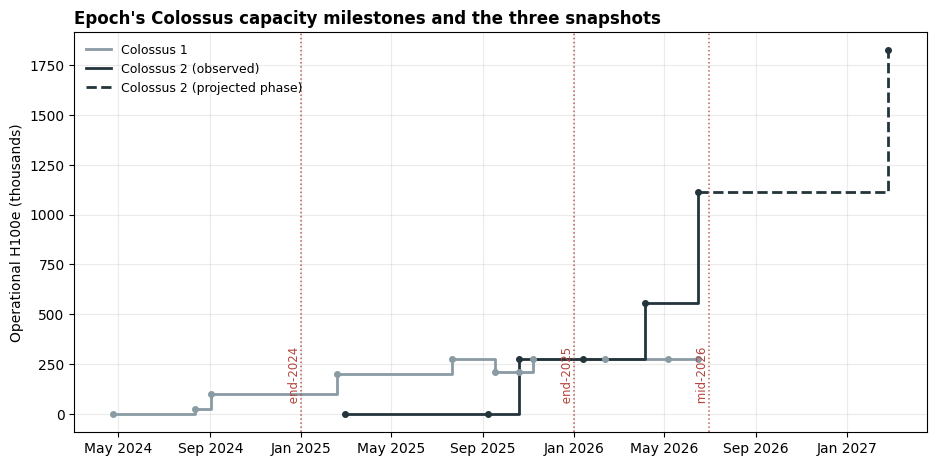

In [5]:
# Timeline chart: milestone step curves per site, the projected C2 phase
# dashed, snapshot dates as vertical lines.
c1_rows = site_milestones("Colossus 1")
c2_rows = site_milestones("Colossus 2")

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.step(c1_rows["Date"], c1_rows["H100 equivalents"] / 1e3, where="post",
        color="#8A9BA3", lw=2, label="Colossus 1")
c2_observed = c2_rows[c2_rows["Date"] <= pd.Timestamp("2026-06-15")]
c2_projected = c2_rows[c2_rows["Date"] >= pd.Timestamp("2026-06-15")]
ax.step(c2_observed["Date"], c2_observed["H100 equivalents"] / 1e3,
        where="post", color=SLATE, lw=2, label="Colossus 2 (observed)")
ax.step(c2_projected["Date"], c2_projected["H100 equivalents"] / 1e3,
        where="post", color=SLATE, lw=2, ls="--",
        label="Colossus 2 (projected phase)")
ax.plot(c1_rows["Date"], c1_rows["H100 equivalents"] / 1e3, "o",
        color="#8A9BA3", ms=4)
ax.plot(c2_rows["Date"], c2_rows["H100 equivalents"] / 1e3, "o",
        color=SLATE, ms=4)

for name, when in SNAPSHOTS.items():
    ax.axvline(when, color="#B4443C", lw=1.1, ls=":", alpha=0.85)
    ax.text(when, ax.get_ylim()[1] * 0.02, f" {name}", rotation=90,
            va="bottom", ha="right", fontsize=8.5, color="#B4443C")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylabel("Operational H100e (thousands)")
ax.set_title("Epoch's Colossus capacity milestones and the three snapshots",
             loc="left", weight="bold")
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.grid(alpha=0.25)
plt.show()

## 2. End-2024: Colossus 1 mid-ramp

No filings exist for this period — the evidence is two company
announcements: **phase 1** (100k H100s) online in September, a hard floor;
and **phase 2** (the second 100k Hoppers, completing the 150k H100 + 50k
H200 configuration) credited by Epoch only in February. The sampled
quantity is **phase 2's completion share at Dec 31**: linear interpolation
between the milestones says 71%, xAI's December "doubling complete"
announcement says 100% (Epoch didn't buy it), and a back-loaded ramp
(H200s arriving late) pulls it down. Prior: normal, 90% CI 0.30–0.95,
median ~0.62 → Colossus ~162k, 90% CI ~130–195k.

**Other compute** is xAI's non-Colossus cloud capacity: the Oracle Grok-2
cluster (20k H100s) anchors the floor, and the S-1's 2024 AI R&D spend
($1.176B, which also covers X R&D, staff/data, and Colossus depreciation)
caps the cloud bill at a ~$300M–$1B/yr run rate.

In [6]:
C1_PHASE1 = 100 * K   # online by September (company announcement)
C1_PHASE2 = 100 * K   # the second 100k Hoppers, credited by Epoch in February

c1_phase2_complete = sq.norm(0.30, 0.95, lclip=0, rclip=1) @ N_SAMPLES
colossus_2024 = C1_PHASE1 + C1_PHASE2 * c1_phase2_complete
other_2024 = PARAMS["other_compute_2024"] @ N_SAMPLES
spacexai_2024 = colossus_2024 + other_2024

summary("C1 phase 2 completion share (Dec 31)", c1_phase2_complete)
summary("Colossus operational (end-2024)", colossus_2024)
summary("Other sites + cloud purchases (end-2024)", other_2024)
summary("SpaceXAI compute, end-2024", spacexai_2024);

C1 phase 2 completion share (Dec 31)
  90% CI : 0.292 – 0.944
  median : 0.624
  mean   : 0.619
Colossus operational (end-2024)
  90% CI : 129k – 194k
  median : 162k
  mean   : 162k
Other sites + cloud purchases (end-2024)
  90% CI : 20k – 60k
  median : 34k
  mean   : 37k
SpaceXAI compute, end-2024
  90% CI : 162k – 236k
  median : 199k
  mean   : 199k


## 3. End-2025: a firm floor, upside from cluster 2

The open level — C1 (~276k) plus C2 cluster 1 (~278k) ≈ **554k** — is
close to a floor: both components are floor-worded disclosures (">220,000
GPUs", "approximately 110,000 GB200") whose power arithmetic checks out
(C1's reported mix implies ~343 MW IT vs Epoch's 340 MW read; if the 30k
B200s were actually Hoppers the power wouldn't add up). Genuine downside
is a few percent of rounding, downtime, and residual mix error.

The sampled quantity is **C2 phase 2's completion share at Dec 31** — the
second cluster (the S-1's 110k GB300s ≈ 278k H100e, Epoch-dated April 6):

- *Satellite says little*: Epoch's Jan 13 read shows the cluster's cooling
  still under construction — a back-loaded ramp.
- *The deck says a lot*: 1.0 GW nameplate at March 31 implies the cluster
  finished around mid-February with phase 3 already partly live — the
  buildout ran well ahead of the satellite credits.
- *Linear interpolation* between its Oct 19 start and either completion
  endpoint brackets the central scenarios (printed below): 43–62% done,
  Colossus ~674–726k.

Prior: clipped normal, 90% CI 0–0.65, median ~0.33 — splitting the
satellite and deck stories, below the linear scenarios. Colossus lands at
median ~645k with a hard floor at the 554k open level.

In [7]:
# Colossus component sizes, from the section-1 record.
C1 = 276 * K           # Colossus 1: 150k H100 + 50k H200 + 30k B200
C2_CLUSTER1 = 278 * K  # Colossus 2 cluster 1: the S-1's 110k GB200s, online Oct 19
C2_CLUSTER2 = 278 * K  # Colossus 2 cluster 2 (phase 2): the S-1's 110k GB300s, Epoch-dated Apr 6

# Linear-interpolation scenarios for C2 cluster 2 at Dec 31, between its
# Oct 19 start and the two completion endpoints.
c2_start = pd.Timestamp("2025-10-19")
for label, end in [("Epoch endpoint (observed Apr 6)", pd.Timestamp("2026-04-06")),
                   ("deck-implied endpoint (~Feb 14)", pd.Timestamp("2026-02-14"))]:
    frac = (SNAPSHOTS["end-2025"] - c2_start).days / (end - c2_start).days
    print(f"{label}: cluster 2 {frac:.0%} done -> Colossus "
          f"{fmt(C1 + C2_CLUSTER1 + frac * C2_CLUSTER2)}")
print(f"floor (cluster 2 not started):      Colossus {fmt(C1 + C2_CLUSTER1)}")

Epoch endpoint (observed Apr 6): cluster 2 43% done -> Colossus 674k
deck-implied endpoint (~Feb 14): cluster 2 62% done -> Colossus 726k
floor (cluster 2 not started):      Colossus 554k


In [8]:
c2_phase2_complete = sq.norm(0, 0.65, lclip=0, rclip=1) @ N_SAMPLES
colossus_2025 = C1 + C2_CLUSTER1 + C2_CLUSTER2 * c2_phase2_complete
other_2025 = PARAMS["other_compute_2025"] @ N_SAMPLES
spacexai_2025 = colossus_2025 + other_2025

p = summary("C2 phase 2 completion share (Dec 31)", c2_phase2_complete)
print(f"  P(none open) = {np.mean(c2_phase2_complete == 0.0):.0%}\n")
summary("Colossus operational (end-2025)", colossus_2025)
summary("Other sites + cloud purchases (end-2025)", other_2025)
summary("SpaceXAI compute, end-2025", spacexai_2025);

C2 phase 2 completion share (Dec 31)
  90% CI : 0.002 – 0.661
  median : 0.319
  mean   : 0.327
  P(none open) = 5%

Colossus operational (end-2025)
  90% CI : 555k – 738k
  median : 643k
  mean   : 645k
Other sites + cloud purchases (end-2025)
  90% CI : 31k – 123k
  median : 61k
  mean   : 67k
SpaceXAI compute, end-2025
  90% CI : 616k – 818k
  median : 708k
  mean   : 712k


The upside-skewed treatment raises end-2025 ~12% over the previous
symmetric one (which centered on the 554k floor), landing at the top of
the gradient update's 600–700k range.

**Other compute** is bounded by the S-1's expense disclosures: the ~$1.8B
2025 increase in infrastructure-and-cloud spending (much of it non-GPU
infrastructure, given GPU depreciation is booked separately) on the
$300M–$1B 2024 baseline implies a $1–2B/yr cloud spend rate, hard ceiling
~$3B — ≈57–114k H100e at ~$2/H100e-hr.

## 4. Mid-2026: the fleet, and which Colossus 2 phases are open

Everything through C2's 400+ MW phase 3 reads firm at ~1.39M H100e: Epoch's
June 15 observation records phase 3 online (an infrastructure inference
from cooling/turbine capacity), and the deck's 1.4 GW nameplate at June 30
corroborates it — without phase 3, C1+C2 is only ~0.75 GW IT,
irreconcilable with the deck under any power definition.

**Colossus firm capacity, mid-2026: `to(1.25M, 1.53M)`** — Epoch's 1.39M
±10%, covering H100e-conversion and satellite power-read error; given the
one-sided deck-vs-Epoch pattern the residual risk leans up, not down.

The **pending phase** is the projected ~Feb 2027 expansion (+712k H100e).
Fifteen days into a ~255-day buildout only a sliver can be energized: the
sampled fraction open is a clipped normal, median ~7% (sheet prior).

In [9]:
colossus_firm_h1_2026 = sq.to(1.25 * M, 1.53 * M) @ N_SAMPLES
C2_PENDING_FEB2027 = 712 * K
phase_open = PARAMS["c2_next_phase_open_h1_2026"] @ N_SAMPLES

colossus_h1_2026 = colossus_firm_h1_2026 + C2_PENDING_FEB2027 * phase_open
other_h1_2026 = PARAMS["other_compute_h1_2026"] @ N_SAMPLES
fleet_h1_2026 = colossus_h1_2026 + other_h1_2026

p = summary("Share of the ~Feb 2027 C2 phase open", phase_open)
print(f"  P(nothing open) = {np.mean(phase_open == 0.0):.0%}\n")
summary("Colossus operational (mid-2026)", colossus_h1_2026)
summary("Total SpaceX fleet (mid-2026)", fleet_h1_2026);

Share of the ~Feb 2027 C2 phase open
  90% CI : 0.000 – 0.152
  median : 0.076
  mean   : 0.076
  P(nothing open) = 5%

Colossus operational (mid-2026)
  90% CI : 1.30M – 1.59M
  median : 1.44M
  mean   : 1.44M
Total SpaceX fleet (mid-2026)
  90% CI : 1.37M – 1.70M
  median : 1.53M
  mean   : 1.53M


## 5. Mid-2026: netting out the cloud sales

Three deals carve capacity out of the fleet from May–July 2026 (no
subtraction applies to the earlier snapshots):

- **Anthropic**: all of Colossus 1 — subtracted at Epoch's 276k point
  level (C1 measurement error appears in both the fleet and the sale, so
  it nets out) — plus a uniform 0–95k H100e of possible spillover into C2:
  the S-1 places the capacity "across COLOSSUS and COLOSSUS II".
- **Google**: one of C2's two ~110k-GPU clusters (~278k H100e), ramping
  through September; the sampled June-30 share is `to(0.15, 0.5)`.
- **Reflection AI**: a small GB300 carve-out billing from July 1, the day
  after the snapshot — uniform 0–45k.

**Cursor stays in**: the S-1 treats its compute agreement as an internal
allocation, not a sale.

In [10]:
# The Anthropic sale is all of C1, the Google deal one C2 cluster — both
# levels unchanged since end-2025, so the section-3 constants apply.
anthropic_spillover = PARAMS["anthropic_c2_spillover"] @ N_SAMPLES
anthropic_sold = C1 + anthropic_spillover

google_ramp = PARAMS["google_ramp_share"] @ N_SAMPLES
google_sold = C2_CLUSTER1 * google_ramp

reflection_sold = PARAMS["reflection_sold_h100e"] @ N_SAMPLES

spacexai_h1_2026 = fleet_h1_2026 - anthropic_sold - google_sold - reflection_sold

summary("Sold to Anthropic (all of C1 + spillover)", anthropic_sold)
summary("Sold to Google (one C2 cluster, ramping)", google_sold)
summary("Sold to Reflection AI", reflection_sold)
summary("SpaceXAI compute, mid-2026", spacexai_h1_2026);

Sold to Anthropic (all of C1 + spillover)
  90% CI : 281k – 367k
  median : 325k
  mean   : 324k
Sold to Google (one C2 cluster, ramping)
  90% CI : 42k – 136k
  median : 76k
  mean   : 81k
Sold to Reflection AI
  90% CI : 2k – 43k
  median : 23k
  mean   : 22k
SpaceXAI compute, mid-2026
  90% CI : 931k – 1.28M
  median : 1.10M
  mean   : 1.10M


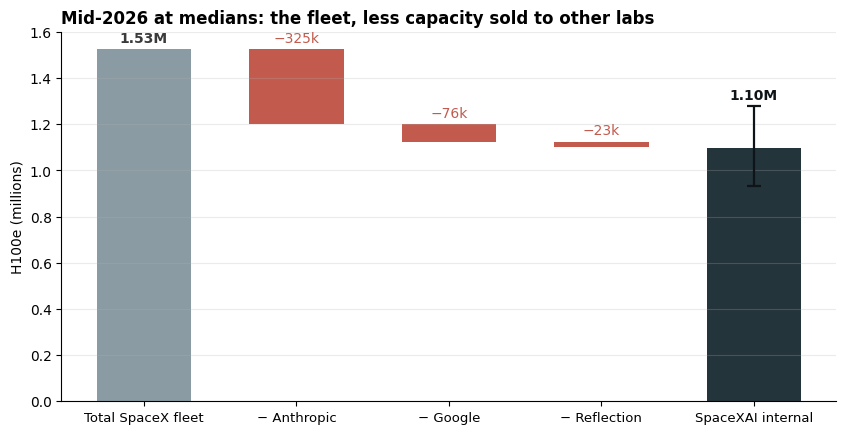

In [11]:
# Waterfall: the fleet at medians, less each sale, down to the internal
# estimate (which carries the full 90% CI).
wf_fleet = np.median(fleet_h1_2026)
wf_sales = [("Anthropic", np.median(anthropic_sold)),
            ("Google", np.median(google_sold)),
            ("Reflection", np.median(reflection_sold))]
wf_lo, wf_med, wf_hi = np.percentile(spacexai_h1_2026, [5, 50, 95])

fig, ax = plt.subplots(figsize=(10, 4.8))
labels = ["Total SpaceX fleet"] + [f"− {n}" for n, _ in wf_sales] + ["SpaceXAI internal"]
running = wf_fleet
ax.bar(0, wf_fleet / 1e6, width=0.62, color="#8A9BA3")
ax.text(0, wf_fleet / 1e6 + 0.03, fmt(wf_fleet), ha="center", fontsize=10,
        fontweight="bold", color="#3a3a3a")
for i, (name, sold) in enumerate(wf_sales, start=1):
    ax.bar(i, sold / 1e6, bottom=(running - sold) / 1e6, width=0.62, color=RED)
    ax.text(i, running / 1e6 + 0.03, f"−{fmt(sold)}", ha="center", fontsize=10,
            color=RED)
    running -= sold
ax.bar(len(labels) - 1, wf_med / 1e6, width=0.62, color=SLATE)
ax.errorbar(len(labels) - 1, wf_med / 1e6,
            yerr=[[(wf_med - wf_lo) / 1e6], [(wf_hi - wf_med) / 1e6]],
            fmt="none", ecolor=SLATE_DARK, elinewidth=1.6, capsize=5,
            capthick=1.6, zorder=3)
ax.text(len(labels) - 1, wf_hi / 1e6 + 0.03, fmt(wf_med), ha="center",
        fontsize=10, fontweight="bold", color=SLATE_DARK)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9.5)
ax.set_ylabel("H100e (millions)")
ax.set_title("Mid-2026 at medians: the fleet, less capacity sold to other labs",
             loc="left", weight="bold")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(alpha=0.25, axis="y")
plt.show()

The medians in the waterfall don't difference exactly to the internal
median (medians aren't additive), but the gap is small. The internal
figure measures *access* rather than use: the sale contracts carry
90–180-day cancellation windows and claw-back rights.

## 6. Results across the three snapshots

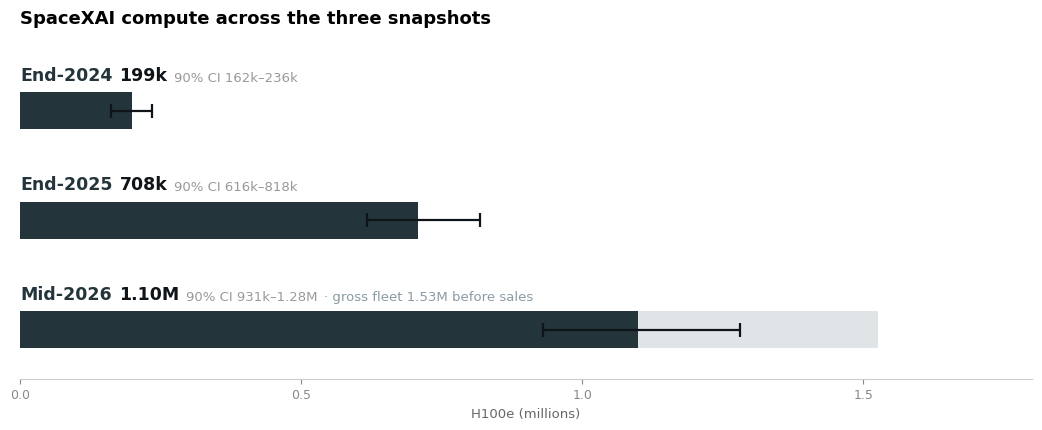

In [12]:
def label_spans(ax, x, y, spans, pad_px=7):
    """Draw text spans left-to-right starting at data-x, each with its own style."""
    for txt, kw in spans:
        t = ax.text(x, y, txt, ha="left", va="bottom", **kw)
        ax.figure.canvas.draw()
        x = ax.transData.inverted().transform(
            (t.get_window_extent().x1 + pad_px, 0))[0]


results = [
    ("End-2024", spacexai_2024, None),
    ("End-2025", spacexai_2025, None),
    ("Mid-2026", spacexai_h1_2026, fleet_h1_2026),
]

fig, ax = plt.subplots(figsize=(11, 4.6))
fig.subplots_adjust(left=0.05, right=0.97, top=0.86, bottom=0.13)
ax.set_xlim(0, 1.8)
ax.set_ylim(-0.45, len(results) - 1 + 0.62)

bar_h = 0.34
for i, (name, samples, gross) in enumerate(results):
    y = len(results) - 1 - i
    lo, med, hi = np.percentile(samples, [5, 50, 95])
    if gross is not None:
        # ghost bar: the gross fleet before netting out cloud sales
        glo, gmed, ghi = np.percentile(gross, [5, 50, 95])
        ax.barh(y, gmed / 1e6, height=bar_h, color="#DFE5E7", zorder=1)
    ax.barh(y, med / 1e6, height=bar_h, color=SLATE, zorder=2)
    ax.errorbar(med / 1e6, y, xerr=[[(med - lo) / 1e6], [(hi - med) / 1e6]],
                fmt="none", ecolor=SLATE_DARK, elinewidth=1.6, capsize=5,
                capthick=1.6, zorder=3)
    spans = [
        (name, dict(fontsize=12.5, fontweight="bold", color=SLATE)),
        (fmt(med), dict(fontsize=12.5, fontweight="bold", color=SLATE_DARK)),
        (f"90% CI {fmt(lo)}–{fmt(hi)}", dict(fontsize=9.5, color="#999999")),
    ]
    if gross is not None:
        spans.append((f"· gross fleet {fmt(gmed)} before sales",
                      dict(fontsize=9.5, color="#8A9BA3")))
    label_spans(ax, 0, y + 0.24, spans)

for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.set_yticks([])
ax.set_xticks([0, 0.5, 1, 1.5])
ax.tick_params(axis="x", colors="#888888", labelsize=9)
ax.set_xlabel("H100e (millions)", color="#666666", fontsize=9.5)
ax.set_title("SpaceXAI compute across the three snapshots",
             loc="left", fontsize=13, weight="bold", pad=14)
plt.show()

## Sensitivity: what moves the mid-2026 estimate most

A one-at-a-time sweep: each sampled input is pinned to its own 5th and
then 95th percentile while everything else keeps its full distribution;
the bar spans the resulting pair of medians.

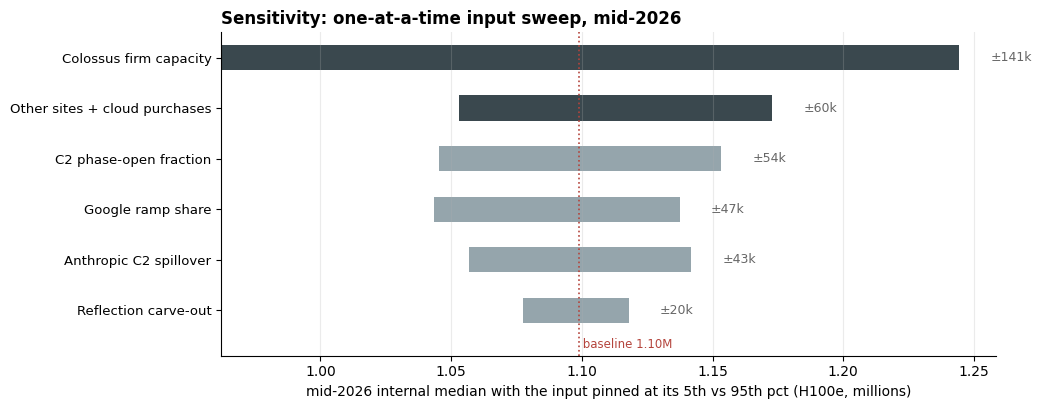

In [13]:
def internal_with(firm=None, phase=None, other=None, spill=None, ramp=None,
                  refl=None):
    """Recompute the mid-2026 internal estimate with some inputs pinned to
    scalars (None keeps the sampled array)."""
    firm = colossus_firm_h1_2026 if firm is None else firm
    phase = phase_open if phase is None else phase
    other = other_h1_2026 if other is None else other
    spill = anthropic_spillover if spill is None else spill
    ramp = google_ramp if ramp is None else ramp
    refl = reflection_sold if refl is None else refl
    fleet = firm + C2_PENDING_FEB2027 * phase + other
    sold = (C1 + spill) + C2_CLUSTER1 * ramp + refl
    return fleet - sold


tornado_inputs = [
    ("Colossus firm capacity", "firm", colossus_firm_h1_2026),
    ("C2 phase-open fraction", "phase", phase_open),
    ("Other sites + cloud purchases", "other", other_h1_2026),
    ("Anthropic C2 spillover", "spill", anthropic_spillover),
    ("Google ramp share", "ramp", google_ramp),
    ("Reflection carve-out", "refl", reflection_sold),
]

baseline_med = np.median(spacexai_h1_2026)
tornado = []
for label, kw, samples in tornado_inputs:
    lo_med = np.median(internal_with(**{kw: np.percentile(samples, 5)}))
    hi_med = np.median(internal_with(**{kw: np.percentile(samples, 95)}))
    tornado.append((label, lo_med, hi_med))
tornado.sort(key=lambda r: abs(r[2] - r[1]), reverse=True)

fig, ax = plt.subplots(figsize=(10, 4.2))
for i, (label, lo_med, hi_med) in enumerate(tornado):
    y = len(tornado) - 1 - i
    left, width = min(lo_med, hi_med), abs(hi_med - lo_med)
    ax.barh(y, width / 1e6, left=left / 1e6, height=0.5,
            color=SLATE if i < 2 else "#8A9BA3", alpha=0.9)
    ax.text(max(lo_med, hi_med) / 1e6 + 0.012, y, f"±{fmt(width / 2)}",
            va="center", fontsize=9, color="#666666")
ax.axvline(baseline_med / 1e6, color="#B4443C", lw=1.2, ls=":")
ax.set_ylim(-0.9, len(tornado) - 0.5)
ax.text(baseline_med / 1e6, -0.8, f" baseline {fmt(baseline_med)}",
        fontsize=8.5, color="#B4443C", va="bottom")
ax.set_yticks(range(len(tornado)))
ax.set_yticklabels([r[0] for r in reversed(tornado)], fontsize=9.5)
ax.set_xlabel("mid-2026 internal median with the input pinned at its 5th vs 95th pct (H100e, millions)")
ax.set_title("Sensitivity: one-at-a-time input sweep, mid-2026",
             loc="left", weight="bold")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(alpha=0.25, axis="x")
plt.show()

## Bottom line

- **End-2024: ~199k H100e** (90% CI ~162–236k). Company announcements
  only; C1 phase 2's completion share is the widest capacity input.
- **End-2025: ~708k H100e** (90% CI ~616–818k). Up ~12% from the previous
  symmetric treatment: the 554k open level is a disclosure-pinned floor,
  with C2 phase 2's completion share supplying the upside.
- **Mid-2026: ~1.10M H100e internal** (90% CI ~931k–1.28M), against a
  gross fleet of ~1.53M before the capacity sold to Anthropic, Google, and
  Reflection. The Q2 deck's 1.4 GW nameplate corroborates phase 3 being
  online at the snapshot.